# 03 - Backtest (Multi-Asset Use Case)

This notebook demonstrates a practical portfolio workflow using **NVDA, AMZN, AAPL**:

1. Load bars for each symbol with `yfinance`.
2. Merge into timestamp baskets compatible with the multi-asset engine.
3. Run a basket strategy that emits per-symbol target weights.
4. Evaluate equity curve, fills, and per-symbol exposure.


In [1]:
from collections import defaultdict, deque

import matplotlib.pyplot as plt
import pandas as pd

from analytics.tearsheet import make_tearsheet_with_details
from data.loaders.yfinance_loader import load_yfinance
from engine.core.backtest_engine import BacktestEngine, EngineConfig
from engine.core.event import MarketEvent


In [2]:
import sys
print(sys.executable)

c:\Users\ziyad\OneDrive\Documents\backtesting\backtesting\.venv\Scripts\python.exe


## 1) Configure universe and engine

`max_abs_weight` limits per-symbol exposure, while fees/slippage/spread model execution realism.


In [3]:
SYMBOLS = ["NVDA", "AMZN", "AAPL"]
PERIOD = "2y"
INTERVAL = "1h"

engine_cfg = EngineConfig(
    initial_cash=100_000,
    fee_bps=1.0,
    slippage_bps=1.0,
    spread_bps=0.0,
    latency_bars=0,
    max_abs_weight=0.6,
    allow_short=False,
)


## 2) Load and align bars

The engine expects a flat `list[MarketEvent]` sorted by timestamp with symbol-tagged bars.


In [4]:
def load_universe(symbols: list[str], period: str, interval: str) -> list[MarketEvent]:
    bars = []
    for symbol in symbols:
        bars.extend(load_yfinance(symbol=symbol, period=period, interval=interval, auto_adjust=True))

    bars.sort(key=lambda b: (b.timestamp, b.symbol))
    return bars


bars = load_universe(SYMBOLS, PERIOD, INTERVAL)
print(f"Loaded {len(bars)} bars across {len(SYMBOLS)} symbols")
print("Date range:", bars[0].timestamp, "->", bars[-1].timestamp)


Loaded 10449 bars across 3 symbols
Date range: 2024-03-07 14:30 -> 2026-03-06 20:30


In [5]:
bars

[MarketEvent(timestamp='2024-03-07 14:30', symbol='AAPL', close=168.97000122070312, open=169.14999389648438, high=169.77999877929688, low=168.49000549316406, volume=15511305.0),
 MarketEvent(timestamp='2024-03-07 14:30', symbol='AMZN', close=176.1300048828125, open=174.8300018310547, high=176.14999389648438, low=173.72000122070312, volume=7088032.0),
 MarketEvent(timestamp='2024-03-07 14:30', symbol='NVDA', close=91.55274963378906, open=90.15800476074219, high=91.5989990234375, low=89.60200500488281, volume=19158572.0),
 MarketEvent(timestamp='2024-03-07 15:30', symbol='AAPL', close=169.27999877929688, open=168.97999572753906, high=169.52999877929688, low=168.61000061035156, volume=8462490.0),
 MarketEvent(timestamp='2024-03-07 15:30', symbol='AMZN', close=175.9803009033203, open=176.1300048828125, high=176.66990661621094, low=175.64999389648438, volume=4281461.0),
 MarketEvent(timestamp='2024-03-07 15:30', symbol='NVDA', close=92.14381408691406, open=91.5719985961914, high=92.27500152

## 3) Define a basket strategy (momentum + equal-weight fallback)

- Compute simple lookback return per symbol.
- Long top-ranked symbol(s), short bottom-ranked symbol(s).
- Keep unranked symbols at 0.


In [6]:
class RankedMomentumBasket:
    def __init__(self, lookback: int = 20, gross_target: float = 1.0):
        self.lookback = lookback
        self.gross_target = gross_target
        self.history: dict[str, deque[float]] = defaultdict(lambda: deque(maxlen=lookback + 1))

    def on_bars(self, bars_by_symbol: dict[str, MarketEvent]) -> dict[str, float]:
        rets = {}
        for symbol, bar in bars_by_symbol.items():
            h = self.history[symbol]
            h.append(bar.close)
            if len(h) < self.lookback + 1:
                continue
            rets[symbol] = (h[-1] / h[0]) - 1.0

        # warmup: stay flat
        if len(rets) < 2:
            return {symbol: 0.0 for symbol in bars_by_symbol}

        ranked = sorted(rets.items(), key=lambda kv: kv[1])
        loser = ranked[0][0]
        winner = ranked[-1][0]

        half = self.gross_target / 2.0
        targets = {symbol: 0.0 for symbol in bars_by_symbol}
        targets[winner] = +half
        targets[loser] = -half
        return targets


## 4) Run backtest


In [7]:
engine = BacktestEngine(engine_cfg)
strategy = RankedMomentumBasket(lookback=20, gross_target=1.0)
result = engine.run_detailed(bars, strategy)

print("Equity points:", len(result.equity_curve))
print("Fills:", len(result.fills))
print("Final cash:", round(engine.portfolio.state.cash, 2))
print("Final positions:", {k: round(v, 4) for k, v in engine.portfolio.state.positions.items()})


Equity points: 20898
Fills: 3919
Final cash: 68655.52
Final positions: {'AAPL': 0.0, 'AMZN': 321.5099, 'NVDA': 0.0}


## 5) Inspect performance summary


In [8]:
# one representative close per timestamp for analytics alignment
close_by_ts = {}
for bar in bars:
    close_by_ts.setdefault(bar.timestamp, bar.close)
prices = list(close_by_ts.values())[: len(result.positions)]

metrics = make_tearsheet_with_details(
    result.equity_curve,
    annualization=252,
    fills=result.fills,
    positions=result.positions,
    prices=prices,
    benchmark_equity=None,
    rolling_window=20,
)

pd.Series(metrics).sort_index()


AvgAbsExposure                0.760949
AvgDrawdownDurationBars     121.696429
CAGR                          0.003819
Calmar                        0.025120
MaxDrawdown                  -0.152019
MaxDrawdownDurationBars    3501.000000
NumTrades                   457.000000
PeakAbsExposure               1.218385
RollingSharpeLast            -5.351592
RollingSharpeMean             0.205320
Sharpe                        0.147389
Turnover                    457.556601
WinRate                       0.509847
dtype: float64

## 6) Visual diagnostics


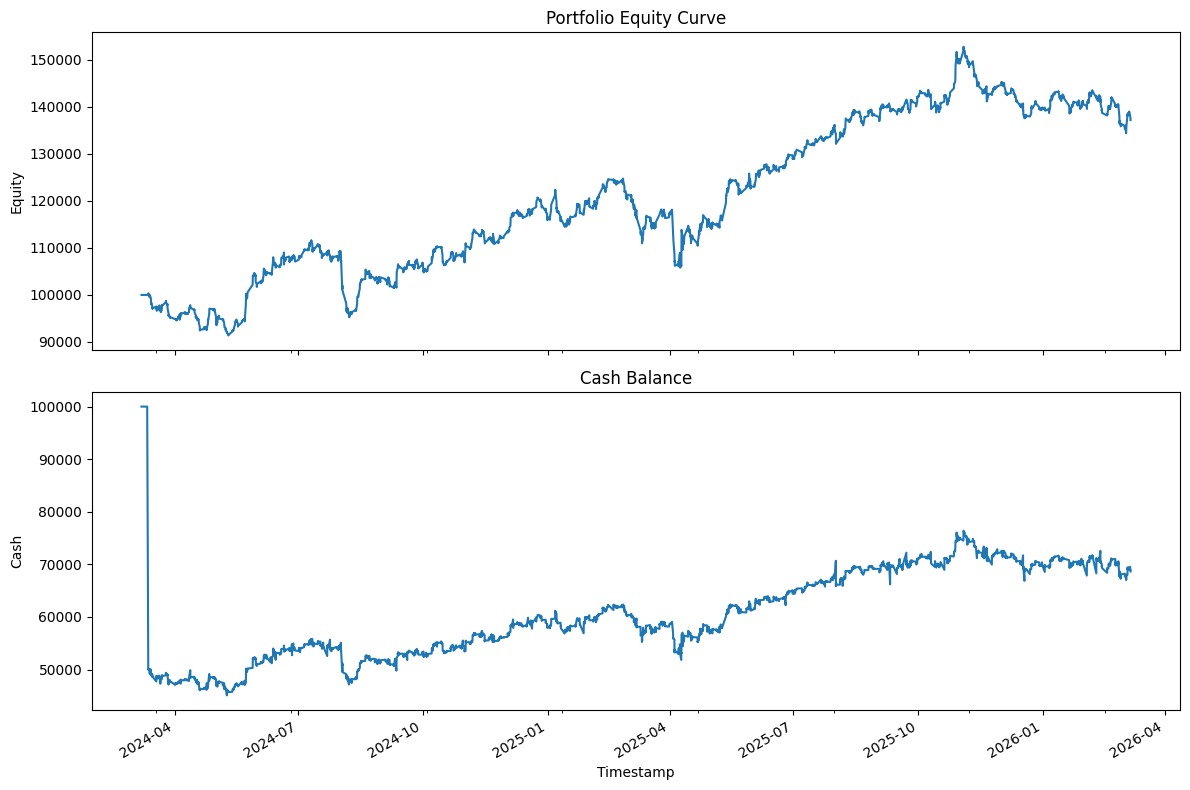

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

step = len(result.equity_curve) // len(result.timestamps)

equity_downsampled = result.equity_curve[::step]

window = 6
equity_means = [
    sum(result.equity_curve[i:i+window]) / window
    for i in range(0, len(result.equity_curve), window)
]


df = pd.DataFrame({
    "timestamp": pd.to_datetime(result.timestamps),
    "equity": equity_means[:len(result.timestamps)],
    "cash": result.cash_series,
}).set_index("timestamp")

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

df["equity"].plot(ax=axes[0], title="Portfolio Equity Curve")
axes[0].set_ylabel("Equity")

df["cash"].plot(ax=axes[1], title="Cash Balance")
axes[1].set_ylabel("Cash")
axes[1].set_xlabel("Timestamp")

plt.tight_layout()
plt.show()

## 7) Fills breakdown by symbol


In [10]:
fills_df = pd.DataFrame([
    {
        "timestamp": f.timestamp,
        "symbol": f.symbol,
        "side": f.side,
        "qty": f.quantity,
        "price": f.fill_price,
        "fee": f.fee,
    }
    for f in result.fills
])


if fills_df.empty:
    print("No fills yet (possibly still in warmup).")
else:
    display(fills_df[0:5])
    display(fills_df.groupby(["symbol", "side"]).size().rename("count"))


,timestamp,symbol,side,qty,price,fee
0,2024-03-11 19:30,AAPL,BUY,289.368609,172.652258,4.996014
1,2024-03-12 13:30,AAPL,BUY,0.230869,172.697169,0.003987
2,2024-03-12 14:30,AAPL,SELL,0.037709,172.502752,0.000650
3,2024-03-12 15:30,AAPL,BUY,0.134166,173.057297,0.002322
4,2024-03-12 16:30,AAPL,SELL,0.435486,173.782516,0.007568


symbol  side
AAPL    BUY     623
        SELL    648
AMZN    BUY     523
        SELL    595
NVDA    BUY     692
        SELL    838
Name: count, dtype: int64

In [11]:
fills_df = pd.DataFrame([
    {
        "timestamp": f.timestamp,
        "symbol": f.symbol,
        "side": f.side,
        "qty": f.quantity,
        "price": f.fill_price,
        "fee": f.fee,
    }
    for f in result.fills
])

positions = pd.Series(result.positions, name="position")

equity = pd.Series(equity_means , name='equity')

cash = pd.Series(result.cash_series, name='cash')



In [12]:
results = pd.concat([positions, equity, cash] , axis=1)

results.head()


,position,equity,cash
0,0.0,100000.0,100000.0
1,0.0,100000.0,100000.0
2,0.0,100000.0,100000.0
3,0.0,100000.0,100000.0
4,0.0,100000.0,100000.0


In [13]:
results.tail()

,position,equity,cash
3478,320.377619,137894.327354,68897.182133
3479,320.102426,137743.417996,68956.278767
3480,320.571889,137661.502089,68855.511917
3481,320.713507,137368.204426,68825.264714
3482,321.509856,137196.629526,68655.520946


In [18]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# -----------------------------
# 1) Build dataframes
# -----------------------------
bars_df = pd.DataFrame([
    {
        "timestamp": pd.to_datetime(b.timestamp),
        "symbol": b.symbol,
        "open": b.open,
        "high": b.high,
        "low": b.low,
        "close": b.close,
        "volume": b.volume,
    }
    for b in bars
]).sort_values(["symbol", "timestamp"])

fills_df = pd.DataFrame([
    {
        "timestamp": pd.to_datetime(f.timestamp),
        "symbol": f.symbol,
        "side": str(f.side).upper(),
        "qty": f.quantity,
        "fill_price": f.fill_price,
        "fee": f.fee,
    }
    for f in result.fills
]).sort_values(["symbol", "timestamp"])

symbols = sorted(bars_df["symbol"].unique())
n = len(symbols)

# -----------------------------
# 2) Create subplots
# -----------------------------
fig = make_subplots(
    rows=n,
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.04,
    row_heights=[0.34, 0.33, 0.33] if n == 3 else None,
    subplot_titles=[f"{sym} Candles + Trades" for sym in symbols]
)

# -----------------------------
# 3) Add one subplot per symbol
# -----------------------------
for i, sym in enumerate(symbols, start=1):
    sym_price = bars_df[bars_df["symbol"] == sym]
    sym_fills = fills_df[fills_df["symbol"] == sym]

    fig.add_trace(
        go.Candlestick(
            x=sym_price["timestamp"],
            open=sym_price["open"],
            high=sym_price["high"],
            low=sym_price["low"],
            close=sym_price["close"],
            name=sym,
            showlegend=False
        ),
        row=i,
        col=1
    )

    if not sym_fills.empty:
        aligned = pd.merge_asof(
            sym_fills.sort_values("timestamp"),
            sym_price[["timestamp", "close"]].sort_values("timestamp"),
            on="timestamp",
            direction="nearest"
        )

        buys = aligned[aligned["side"] == "BUY"]
        sells = aligned[aligned["side"] == "SELL"]

        if not buys.empty:
            fig.add_trace(
                go.Scatter(
                    x=buys["timestamp"],
                    y=buys["close"],
                    mode="markers",
                    name=f"{sym} BUY",
                    marker=dict(
                        symbol="triangle-up",
                        color="orange",
                        size=12,
                        line=dict(color="black", width=1)
                    ),
                    customdata=buys[["qty", "fill_price", "fee"]].to_numpy(),
                    hovertemplate=(
                        f"{sym} BUY<br>"
                        "Time: %{x}<br>"
                        "Price: %{y:.2f}<br>"
                        "Qty: %{customdata[0]:.4f}<br>"
                        "Fill: %{customdata[1]:.2f}<br>"
                        "Fee: %{customdata[2]:.4f}"
                        "<extra></extra>"
                    ),
                ),
                row=i,
                col=1
            )

        if not sells.empty:
            fig.add_trace(
                go.Scatter(
                    x=sells["timestamp"],
                    y=sells["close"],
                    mode="markers",
                    name=f"{sym} SELL",
                    marker=dict(
                        symbol="triangle-down",
                        color="blue",
                        size=12,
                        line=dict(color="black", width=1)
                    ),
                    customdata=sells[["qty", "fill_price", "fee"]].to_numpy(),
                    hovertemplate=(
                        f"{sym} SELL<br>"
                        "Time: %{x}<br>"
                        "Price: %{y:.2f}<br>"
                        "Qty: %{customdata[0]:.4f}<br>"
                        "Fill: %{customdata[1]:.2f}<br>"
                        "Fee: %{customdata[2]:.4f}"
                        "<extra></extra>"
                    ),
                ),
                row=i,
                col=1
            )

    fig.update_yaxes(
        title_text=sym,
        fixedrange=False,
        automargin=True,
        row=i,
        col=1
    )

# -----------------------------
# 4) Hide non-trading gaps
# -----------------------------
fig.update_xaxes(
    rangebreaks=[
        dict(bounds=["sat", "mon"]),
        dict(bounds=[16, 9.5], pattern="hour")
    ]
)

# -----------------------------
# 5) Disable sliders everywhere
# -----------------------------
fig.update_xaxes(rangeslider_visible=False)

# Enable only on bottom subplot
fig.update_xaxes(
    rangeslider_visible=True,
    rangeslider_thickness=0.06,
    rangeselector=dict(
        buttons=[
            dict(count=1, label="1m", step="month", stepmode="backward"),
            dict(count=3, label="3m", step="month", stepmode="backward"),
            dict(count=6, label="6m", step="month", stepmode="backward"),
            dict(count=1, label="1y", step="year", stepmode="backward"),
            dict(step="all", label="All"),
        ]
    ),
    row=n,
    col=1
)

# -----------------------------
# 6) Layout improvements
# -----------------------------
fig.update_layout(
    title="Per-Symbol Candlestick Charts with Buy/Sell Markers",
    height=430 * n,
    hovermode="closest",
    dragmode="zoom",
    legend=dict(
        orientation="v",
        yanchor="top",
        y=1,
        xanchor="left",
        x=1.02
    ),
    margin=dict(l=80, r=200, t=80, b=80),
)

fig.show()

In [15]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

bars_df = pd.DataFrame([
    {
        "timestamp": pd.to_datetime(b.timestamp),
        "symbol": b.symbol,
        "open": b.open,
        "high": b.high,
        "low": b.low,
        "close": b.close,
        "volume": b.volume,
    }
    for b in bars
]).sort_values(["symbol", "timestamp"])

fills_df = pd.DataFrame([
    {
        "timestamp": pd.to_datetime(f.timestamp),
        "symbol": f.symbol,
        "side": str(f.side).upper(),
        "qty": f.quantity,
        "fill_price": f.fill_price,
        "fee": f.fee,
    }
    for f in result.fills
]).sort_values(["symbol", "timestamp"])

symbols = sorted(bars_df["symbol"].unique())
n = len(symbols)

fig = make_subplots(
    rows=n,
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.04,
    subplot_titles=[f"{sym} Candles + Trades" for sym in symbols]
)

for i, sym in enumerate(symbols, start=1):
    sym_price = bars_df[bars_df["symbol"] == sym].copy()
    sym_fills = fills_df[fills_df["symbol"] == sym].copy()

    fig.add_trace(
        go.Candlestick(
            x=sym_price["timestamp"],
            open=sym_price["open"],
            high=sym_price["high"],
            low=sym_price["low"],
            close=sym_price["close"],
            name=sym,
            showlegend=False
        ),
        row=i,
        col=1
    )

    if not sym_fills.empty:
        aligned = pd.merge_asof(
            sym_fills.sort_values("timestamp"),
            sym_price[["timestamp", "close"]].sort_values("timestamp"),
            on="timestamp",
            direction="nearest"
        )

        buys = aligned[aligned["side"] == "BUY"]
        sells = aligned[aligned["side"] == "SELL"]

        if not buys.empty:
            fig.add_trace(
                go.Scatter(
                    x=buys["timestamp"],
                    y=buys["close"],
                    mode="markers",
                    name=f"{sym} BUY",
                    marker=dict(symbol="triangle-up", color="green", size=10),
                    customdata=buys[["qty", "fill_price", "fee"]].to_numpy(),
                    hovertemplate=(
                        f"{sym} BUY<br>"
                        "Time: %{x}<br>"
                        "Price: %{y:.2f}<br>"
                        "Qty: %{customdata[0]:.4f}<br>"
                        "Fill: %{customdata[1]:.2f}<br>"
                        "Fee: %{customdata[2]:.4f}<extra></extra>"
                    ),
                    showlegend=(i == 1),
                ),
                row=i,
                col=1
            )

        if not sells.empty:
            fig.add_trace(
                go.Scatter(
                    x=sells["timestamp"],
                    y=sells["close"],
                    mode="markers",
                    name=f"{sym} SELL",
                    marker=dict(symbol="triangle-down", color="red", size=10),
                    customdata=sells[["qty", "fill_price", "fee"]].to_numpy(),
                    hovertemplate=(
                        f"{sym} SELL<br>"
                        "Time: %{x}<br>"
                        "Price: %{y:.2f}<br>"
                        "Qty: %{customdata[0]:.4f}<br>"
                        "Fill: %{customdata[1]:.2f}<br>"
                        "Fee: %{customdata[2]:.4f}<extra></extra>"
                    ),
                    showlegend=(i == 1),
                ),
                row=i,
                col=1
            )

# Disable slider everywhere first
fig.update_xaxes(rangeslider_visible=False)

# Enable it only on the last subplot
fig.update_xaxes(
    rangeslider_visible=True,
    rangeselector=dict(
        buttons=[
            dict(count=1, label="1m", step="month", stepmode="backward"),
            dict(count=3, label="3m", step="month", stepmode="backward"),
            dict(count=6, label="6m", step="month", stepmode="backward"),
            dict(count=1, label="1y", step="year", stepmode="backward"),
            dict(step="all", label="All"),
        ]
    ),
    row=n,
    col=1
)

fig.update_layout(
    title="Per-Symbol Candlestick Charts with Buy/Sell Markers",
    height=420 * n,
    hovermode="x unified"
)

fig.show()